In [18]:
!pip install pubchempy pandas rdkit

In [19]:
from rdkit import Chem
print("RDKit working")

RDKit working


In [20]:
molecules = [
    "Aspirin",
    "Caffeine",
    "Ibuprofen",
    "Paracetamol",
    "Benzene",
    "Toluene",
    "Phenol",
    "Acetone",
    "Ethanol",
    "Methanol",
    "Glucose",
    "Acetic acid",
    "Citric acid",
    "Nicotine",
    "Cholesterol",
    "Urea",
    "Aniline",
    "Naphthalene",
    "Acetaldehyde",
    "Formaldehyde"
]

In [21]:
import pubchempy as pcp

compound = pcp.get_compounds("Aspirin", "name")

print(compound)
print(len(compound))

[Compound(2244)]
1


In [22]:
import pubchempy as pcp
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

molecules = [
    "Aspirin",
    "Caffeine",
    "Ibuprofen",
    "Paracetamol",
    "Benzene",
    "Toluene",
    "Phenol",
    "Acetone",
    "Ethanol",
    "Methanol",
    "Glucose",
    "Acetic acid",
    "Citric acid",
    "Nicotine",
    "Cholesterol",
    "Urea",
    "Aniline",
    "Naphthalene",
    "Acetaldehyde",
    "Formaldehyde"
]

data = []
for name in molecules:

    try:
        compound = pcp.get_compounds(name, 'name')[0]

        smiles = compound.isomeric_smiles
        formula = compound.molecular_formula

        mol = Chem.MolFromSmiles(smiles)

        mw = Descriptors.MolWt(mol)
        tpsa = Descriptors.TPSA(mol)
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        logp = Descriptors.MolLogP(mol)

        data.append([
            name,
            formula,
            mw,
            tpsa,
            hbd,
            hba,
            logp
        ])

        print("Added:", name)

    except Exception as e:
        print("Failed:", name)
        print(e)

Added: Aspirin


/tmp/ipykernel_1727/3745894131.py:35: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  smiles = compound.isomeric_smiles


Added: Caffeine
Added: Ibuprofen
Added: Paracetamol
Added: Benzene
Added: Toluene
Added: Phenol
Added: Acetone
Added: Ethanol
Added: Methanol
Added: Glucose
Added: Acetic acid
Added: Citric acid
Added: Nicotine
Added: Cholesterol
Added: Urea
Added: Aniline
Added: Naphthalene
Added: Acetaldehyde
Added: Formaldehyde


In [23]:
import pubchempy as pcp

compound = pcp.get_compounds("Aspirin", "name")

print(compound)
print(len(compound))

[Compound(2244)]
1


In [24]:
df = pd.DataFrame(
    data,
    columns=[
        "Name",
        "Formula",
        "MW",
        "TPSA",
        "HBD",
        "HBA",
        "LogP"
    ]
)

print(df.head())

          Name    Formula       MW   TPSA  HBD  HBA    LogP
0      Aspirin     C9H8O4  180.159  63.60    1    3  1.3101
1     Caffeine  C8H10N4O2  194.194  61.82    0    3 -1.0293
2    Ibuprofen   C13H18O2  206.285  37.30    1    1  3.0732
3  Paracetamol    C8H9NO2  151.165  49.33    2    2  1.3506
4      Benzene       C6H6   78.114   0.00    0    0  1.6866


In [25]:
df = pd.DataFrame(
    data,
    columns=[
        "Name",
        "Formula",
        "MW",
        "TPSA",
        "HBD",
        "HBA",
        "LogP"
    ]
)

print(df)

            Name    Formula       MW    TPSA  HBD  HBA     LogP
0        Aspirin     C9H8O4  180.159   63.60    1    3  1.31010
1       Caffeine  C8H10N4O2  194.194   61.82    0    3 -1.02930
2      Ibuprofen   C13H18O2  206.285   37.30    1    1  3.07320
3    Paracetamol    C8H9NO2  151.165   49.33    2    2  1.35060
4        Benzene       C6H6   78.114    0.00    0    0  1.68660
5        Toluene       C7H8   92.141    0.00    0    0  1.99502
6         Phenol      C6H6O   94.113   20.23    1    1  1.39220
7        Acetone      C3H6O   58.080   17.07    0    1  0.59530
8        Ethanol      C2H6O   46.069   20.23    1    1 -0.00140
9       Methanol       CH4O   32.042   20.23    1    1 -0.39150
10       Glucose    C6H12O6  180.156  110.38    5    6 -3.22140
11   Acetic acid     C2H4O2   60.052   37.30    1    1  0.09090
12   Citric acid     C6H8O7  192.123  132.13    4    4 -1.24850
13      Nicotine   C10H14N2  162.236   16.13    0    2  1.84830
14   Cholesterol    C27H46O  386.664   2

In [26]:
df.to_csv("molecular_dataset.csv",index=False)

In [27]:
print(df.shape)

(20, 7)


In [28]:
!pip install scikit-learn

In [29]:
import pandas as pd
df = pd.read_csv("molecular_dataset.csv")
print(df.head())

          Name    Formula       MW   TPSA  HBD  HBA    LogP
0      Aspirin     C9H8O4  180.159  63.60    1    3  1.3101
1     Caffeine  C8H10N4O2  194.194  61.82    0    3 -1.0293
2    Ibuprofen   C13H18O2  206.285  37.30    1    1  3.0732
3  Paracetamol    C8H9NO2  151.165  49.33    2    2  1.3506
4      Benzene       C6H6   78.114   0.00    0    0  1.6866


In [30]:
import pandas as pd

df = pd.read_csv("molecular_dataset.csv")

print(df)

            Name    Formula       MW    TPSA  HBD  HBA     LogP
0        Aspirin     C9H8O4  180.159   63.60    1    3  1.31010
1       Caffeine  C8H10N4O2  194.194   61.82    0    3 -1.02930
2      Ibuprofen   C13H18O2  206.285   37.30    1    1  3.07320
3    Paracetamol    C8H9NO2  151.165   49.33    2    2  1.35060
4        Benzene       C6H6   78.114    0.00    0    0  1.68660
5        Toluene       C7H8   92.141    0.00    0    0  1.99502
6         Phenol      C6H6O   94.113   20.23    1    1  1.39220
7        Acetone      C3H6O   58.080   17.07    0    1  0.59530
8        Ethanol      C2H6O   46.069   20.23    1    1 -0.00140
9       Methanol       CH4O   32.042   20.23    1    1 -0.39150
10       Glucose    C6H12O6  180.156  110.38    5    6 -3.22140
11   Acetic acid     C2H4O2   60.052   37.30    1    1  0.09090
12   Citric acid     C6H8O7  192.123  132.13    4    4 -1.24850
13      Nicotine   C10H14N2  162.236   16.13    0    2  1.84830
14   Cholesterol    C27H46O  386.664   2

In [31]:
X = df[["MW", "TPSA", "HBD", "HBA"]]

print(X.head())

y = df["LogP"]

print(y.head())

        MW   TPSA  HBD  HBA
0  180.159  63.60    1    3
1  194.194  61.82    0    3
2  206.285  37.30    1    1
3  151.165  49.33    2    2
4   78.114   0.00    0    0
0    1.3101
1   -1.0293
2    3.0732
3    1.3506
4    1.6866
Name: LogP, dtype: float64


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16, 4)
(4, 4)


In [33]:
from sklearn.ensemble import RandomForestRegressor

In [34]:
model = RandomForestRegressor(random_state=42)

In [35]:
model.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

In [36]:
predictions = model.predict(X_test)

print(predictions)

[1.079233  1.8166112 0.213538  1.661875 ]


In [37]:
from sklearn.metrics import r2_score

In [38]:
r2 = r2_score(y_test,predictions)

print("R² Score =", r2)

R² Score = 0.08319747880836492


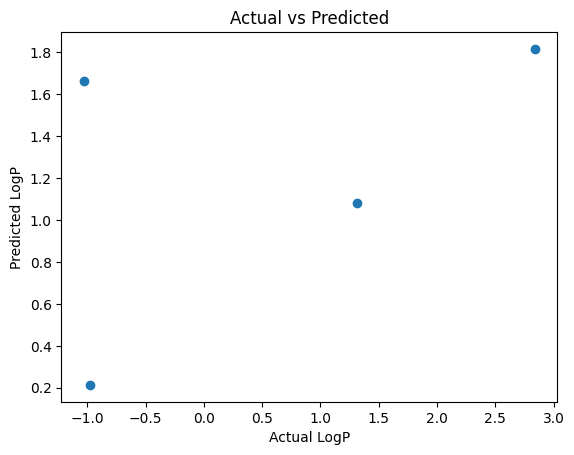

In [39]:
import matplotlib.pyplot as plt

plt.scatter(y_test,predictions)

plt.xlabel("Actual LogP")
plt.ylabel("Predicted LogP")
plt.title("Actual vs Predicted")

plt.show()

In [42]:
print(X.head())


        MW   TPSA  HBD  HBA
0  180.159  63.60    1    3
1  194.194  61.82    0    3
2  206.285  37.30    1    1
3  151.165  49.33    2    2
4   78.114   0.00    0    0


In [43]:
print(y.head())

0    1.3101
1   -1.0293
2    3.0732
3    1.3506
4    1.6866
Name: LogP, dtype: float64


In [44]:
print(r2)

0.08319747880836492
